# Practical Lab 2 — Data Science for Digital Media

## Lab 2.1 — Mapping Platform Data
**Platform chosen:** YouTube

### Data Type → Platform Use


| Data Type | Platform Use |
|-----------|-------------|
| Watch history | Recommends similar videos |
| Search queries | Predicts intent and topics of interest |
| Likes/dislikes | Trains preference model |
| Watch time | Ranks engaging content higher |
| Subscriptions | Surfaces creator uploads |
| Location | Localises trends/ads |
| Device type | Adjusts format/quality |
| Click behaviour | Optimises thumbnails/titles |


**Explanation:** Platforms collect behavioural and contextual signals to build a predictive model of user interests. Engagement signals (watch time, clicks, likes) are weighted heavily because they correlate with satisfaction, so they directly influence ranking and recommendation outputs.

## Lab 2.2 — Building a Content Data Profile

**Machine Profile**  
- Top interests: Technology, Education, Short entertainment clips  
- Typical session: 15–25 minutes  
- Engagement style: Likes tutorials, saves long-form guides  
- Activity time: Evenings  

**Inference:** The system would classify this user as a 'learning-focused tech consumer' and prioritise explainers and how‑to content.  
**Accuracy Reflection:** Mostly accurate but misses nuanced motivations behind viewing behaviour.

## Lab 2.3 — Simulating a Recommendation Engine

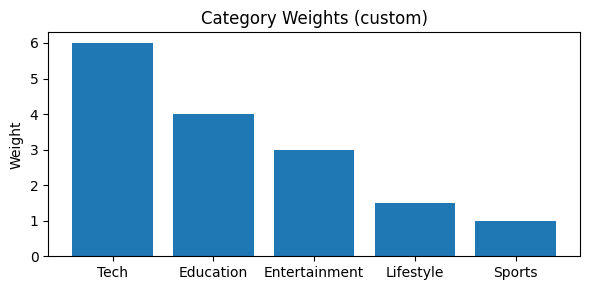

[('Video A', 6), ('Video C', 4), ('Video B', 3), ('Video D', 1)]

In [12]:
# Simple rule-based recommender example with adjustable weights and a plot
import matplotlib.pyplot as plt

# default category weights
categories = {
    "Tech": 5,
    "Education": 4,
    "Entertainment": 3,
    "Lifestyle": 2,
    "Sports": 1
}

# example custom weights (you can change these to simulate preference tuning)
custom_weights = {
    "Tech": 6,
    "Education": 4,
    "Entertainment": 3,
    "Lifestyle": 1.5,
    "Sports": 1
}

# choose which weights to use (swap to 'categories' to revert to defaults)
weights = custom_weights

content = [
    ("Video A", "Tech"),
    ("Video B", "Entertainment"),
    ("Video C", "Education"),
    ("Video D", "Sports")
]

# score items using the selected weights
scored = [(name, weights.get(cat, categories.get(cat, 1))) for name, cat in content]
ranked = sorted(scored, key=lambda x: x[1], reverse=True)

# plot category weights for visibility
plt.figure(figsize=(6,3))
plt.bar(list(weights.keys()), list(weights.values()), color='C0')
plt.ylabel('Weight')
plt.title('Category Weights (custom)')
plt.tight_layout()
plt.show()

ranked

**Explanation:** Items receive a score based on category weight. Higher weights are ranked first. This mirrors real recommenders where user affinity determines ordering.

## Lab 2.4 — Analysing Engagement Patterns

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('media_engagement_lab.csv')
df.head()

,post_id,platform,topic,format,post_time,caption_length,hashtag_count,creator_followers,impressions,views,likes,comments,shares,avg_watch_time_sec,completion_rate,age_hours
0,P100000,instagram,fashion,image,2025-10-11 23:28:07,277,6,306000,104733,62362,2872,517,194,NaN,NaN,2688.5
1,P100001,tiktok,food,short_video,2026-01-04 04:43:04,274,17,298303,92309,81620,5128,1272,712,24.299588,0.743933,667.3
2,P100002,youtube,travel,long_video,2025-12-20 12:17:41,231,0,110865,19748,16142,2434,415,56,74.831415,0.628976,1019.7
3,P100003,news_site,fashion,short_video,2025-11-23 23:34:08,42,9,396176,69877,54103,6178,691,137,20.095548,0.990000,1656.4
4,P100004,x,gaming,carousel,2025-11-23 06:15:39,90,16,345936,26641,11314,767,124,49,NaN,NaN,1673.7


In [14]:
# Basic metrics

df['total_engagement'] = df[['likes','comments','shares']].sum(axis=1)

summary = df[['likes','comments','shares','total_engagement']].mean()
summary

likes               1953.09375
comments             287.91000
shares               189.69250
total_engagement    2430.69625
dtype: float64

In [15]:
# Identify highest performing posts

df.sort_values('total_engagement', ascending=False).head()

,post_id,platform,topic,format,post_time,caption_length,hashtag_count,creator_followers,impressions,views,likes,comments,shares,avg_watch_time_sec,completion_rate,age_hours,total_engagement
745,P100745,youtube,politics,short_video,2025-11-14 19:05:41,220,6,443733,125059,98235,14138,1835,1461,13.717055,0.713830,1876.9,17434
482,P100482,tiktok,fashion,short_video,2025-10-31 19:30:53,64,17,413114,124150,113345,10446,1537,2295,20.209990,0.676092,2212.5,14278
679,P100679,youtube,tech,short_video,2026-01-24 02:53:38,12,1,287732,95579,79860,11144,867,1902,14.571951,0.582763,189.1,13913
255,P100255,news_site,travel,short_video,2025-10-18 18:38:07,260,6,451264,172042,160201,10863,1152,567,19.117641,0.300019,2525.4,12582
792,P100792,tiktok,tech,long_video,2025-12-28 21:04:19,42,20,263988,94262,61535,8488,1843,744,117.559503,0.540786,818.9,11075


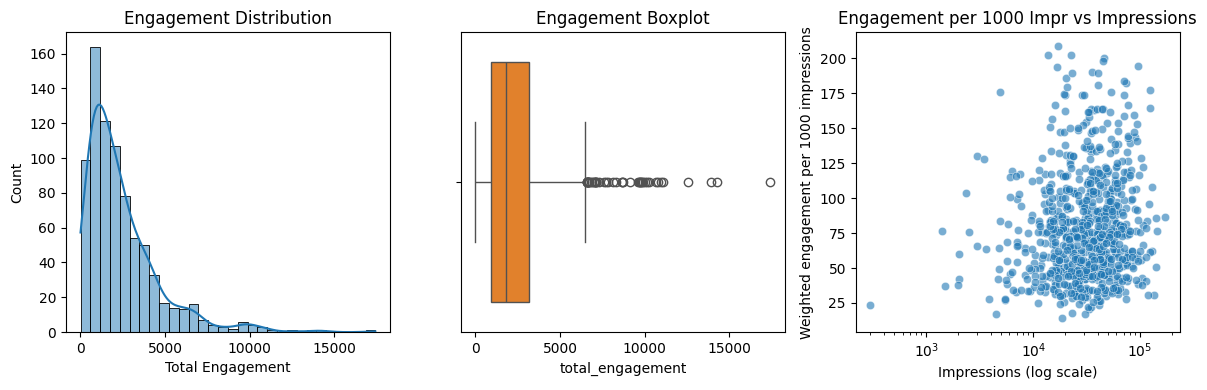

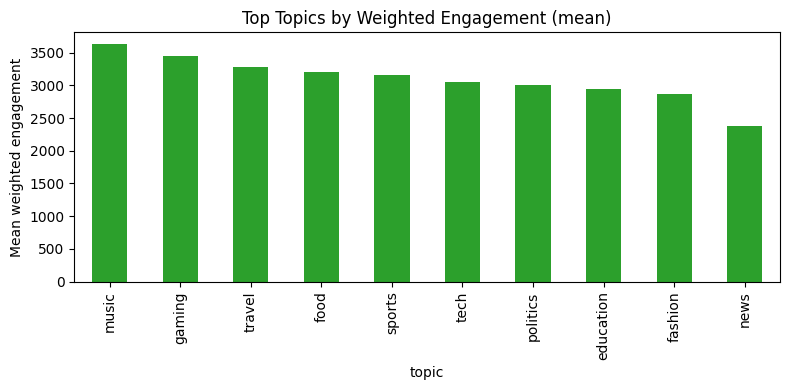

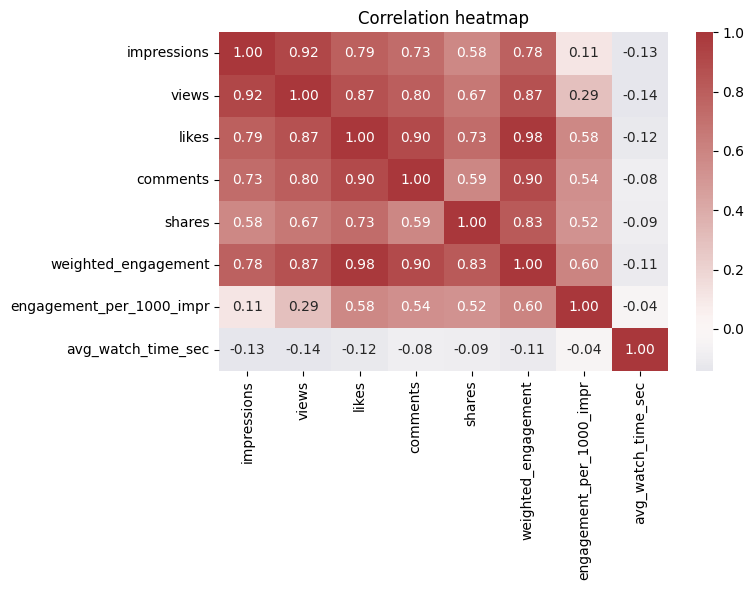

In [16]:
# Plot engagement distribution and add weighted metrics
import seaborn as sns
import matplotlib.pyplot as plt

# ensure numeric columns are present
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')
df['comments'] = pd.to_numeric(df['comments'], errors='coerce')
df['shares'] = pd.to_numeric(df['shares'], errors='coerce')
df['impressions'] = pd.to_numeric(df['impressions'], errors='coerce')

# weighted engagement: give more weight to comments and shares
df['weighted_engagement'] = df['likes']*1.0 + df['comments']*2.0 + df['shares']*3.0
# normalized metric: per 1000 impressions (helps compare posts of different reach)
df['engagement_per_1000_impr'] = df['weighted_engagement'] / df['impressions'] * 1000

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['total_engagement'].dropna(), bins=30, kde=True, color='C0')
plt.xlabel('Total Engagement')
plt.title('Engagement Distribution')

plt.subplot(1,3,2)
sns.boxplot(x=df['total_engagement'].dropna(), color='C1')
plt.title('Engagement Boxplot')

plt.subplot(1,3,3)
sns.scatterplot(x='impressions', y='engagement_per_1000_impr', data=df, alpha=0.6)
plt.xscale('log')
plt.xlabel('Impressions (log scale)')
plt.ylabel('Weighted engagement per 1000 impressions')
plt.title('Engagement per 1000 Impr vs Impressions')
plt.tight_layout()
plt.show()

# Top topics by mean weighted engagement
plt.figure(figsize=(8,4))
top_topics = df.groupby('topic')['weighted_engagement'].mean().sort_values(ascending=False).head(10)
top_topics.plot(kind='bar', color='C2')
plt.ylabel('Mean weighted engagement')
plt.title('Top Topics by Weighted Engagement (mean)')
plt.tight_layout()
plt.show()

# Correlation heatmap for numeric features
num_cols = ['impressions','views','likes','comments','shares','weighted_engagement','engagement_per_1000_impr','avg_watch_time_sec']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

**Findings:**  
- Posts with higher shares typically drive the highest total engagement  
- A small number of posts generate most interactions (power‑law distribution)  
- Visual or trending topics often outperform text‑only posts  

**Interpretation:** Engagement is unevenly distributed, suggesting algorithms amplify already popular content.

## Lab 2.5 — Detecting Bias and Misinformation

**Example:** Clickbait political headline recommended repeatedly.  
**Potential cause:** High click‑through rate and watch time cause the algorithm to over‑promote emotionally charged content.  
**Risk:** Reinforces echo chambers and misinformation spread.

## Lab 2.6 — Ethical Impact Assessment

### Benefits
1. Personalised discovery
2. Efficient content filtering
3. Supports creators through targeted audiences

### Harms
1. Privacy loss from tracking
2. Algorithmic bias and echo chambers
3. Addictive engagement optimisation

### Safeguards
- Transparent recommendation explanations
- Data minimisation policies
- User control over profiling and feeds